# Ad-spend Decision Making

In this project you will demonstrate inflated (over-optimistic) forecasts due to selection bias and diminishing returns.

1. Assume all spending and demand amounts are in \$1000's.
1. Create a Python function to compute the "true demand" you can expect for a given amount of Youtube and Facebook ad spending
Use the formula: demand = 1000 + 14 yt^.8 + 20 fb^.7

1. In a markdown cell, explain/illustrate how that function exhibits diminishing returns.

1. Create a Python function that will run one simulation.  In that simulation:
    - Run 52 weekly experiments; create NumPy arrays to hold the information
        - each week, you will spend between \$25 and 75 on Youtube (chosen uniformly)
        - likewise, you will spend between \$25 and 75 on Facebook (chosen uniformly)
        - weekly sales will be computed from your true demand function, plus noise that should be normally distributed with mean 0 and standard deviation \$100
        - put Youtube_Spend, Facebook_Spend, and Sales in a dataframe, in order to do a multi-linear regression (with a constant term)
    - Based on the regression coefficients for Youtube and Facebook, in the simulated week, the marketing director will put a full  100 budget into the one with the higher coefficient, and none toward the other channel.  e.g. suppose the Youtube coefficient is 6.5 and the Facebook coefficent is 4.8; then the entire marketing budget (\$100) goes to Youtube.
    - Using your linear model (with coefficients based on your 52 weeks of data), make a sales forecast if you put \$100 ad budget into your chosen channel.
    - Compute an actual realized sales amount from your true demand function, plus noise ~ N(0,100)
    - Your simulation function should return the chosen channel, the sales forecast, and the actual sales computed for this simulation.

1. Use a for loop to run your simulation many times (say 1000 sims), in order to do a Monte-Carlo simulation analysis.  
    - Store the chosen channels, sales forecasts, and actual sales in arrays, which you can convert to a dataframe.
    - Print the percentage of simulations in which Youtube and Facebook were chosen.
    - Contrast the mean sales forecasted vs the mean of actual sales.
    - Create a plot with histograms for the forecasted and actual sales.

1. Update your functions to allow the noise standard deviation to be specified.  It was 100 in the instructions above.  Re-run your Monte-Carlo analysis with less noise, say 70.  Comment on any differences you observe.

1. In reality, you won't have omniscient knowledge of the "true demand" function.  But suppose you did, and could optimally split your \$100 budget between Youtube and Facebook.  How much would you put on each?  (Hint: if you put x on Youtube, you'll put 100-x on Facebook; what value of x maximizes demand?)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# non-linear demand function with diminishing returns
def true_demand(youtube_spend,facebook_spend):
    return 1000 + 14.0 * (youtube_spend ** .8) + 20.0 * (facebook_spend ** .7)

In [3]:
def run_sim (noise_std=100.0, detail=False):

    # run a year of weekly experiments with random spending
    n_samples = 52

    # each week, allocate from 25% to 75% of your budget to each platform
    total_budget = 100.0 
    youtube_spend = np.random.uniform(.25*total_budget, .75*total_budget, size=n_samples)
    facebook_spend = np.random.uniform(.25*total_budget, .75*total_budget, size=n_samples)

    # Random noise in observed data
    noise = np.random.normal(loc=0.0, scale=noise_std, size=n_samples)

    # Calculate true observed sales (signal + noise)
    sales = true_demand(youtube_spend, facebook_spend) + noise

    # Package into DataFrame
    df = pd.DataFrame({
        'YouTube_Spend': youtube_spend,
        'Facebook_Spend': facebook_spend,
        'Sales': sales
    })
    if (detail):
        print(df.head())

    X = df[['YouTube_Spend', 'Facebook_Spend']]
    X_with_const = sm.add_constant(X) 
    y = df['Sales']

    linear_model = sm.OLS(y, X_with_const).fit()

    # Extract fitted coefficients
    b0 = linear_model.params['const']
    b_yt = linear_model.params['YouTube_Spend']
    b_fb = linear_model.params['Facebook_Spend']

    rmse = np.sqrt(np.mean(linear_model.resid**2))

    # select channel with the higher linear spend coefficient
    if b_yt > b_fb:
        chosen_channel = 'YouTube'
        opt_yt_spend = total_budget
        opt_fb_spend = 0.0
    else:
        chosen_channel = 'Facebook'
        opt_yt_spend = 0.0
        opt_fb_spend = total_budget

    # Calculate "Rosy" Deterministic Linear Prediction
    rosy_forecast = b0 + (b_yt * opt_yt_spend) + (b_fb * opt_fb_spend)

    # simulate actual sales if you go all-in with your chosen channel
    actual_sales = true_demand(opt_yt_spend, opt_fb_spend) + np.random.normal(loc=0.0, scale=noise_std)

    if (detail):
        print(linear_model.summary())
        print(f"RMSE:                   {rmse:.2f}")
        print("--- STRATEGY BASED ON FITTED LINEAR COEFFICIENTS ---")
        print(f"Intercept (b0_hat):    {b0:.2f}")
        print(f"Fitted YouTube Coeff (b_yt):  {b_yt:.4f}")
        print(f"Fitted Facebook Coeff (b_fb): {b_fb:.4f}")
        print(f"\nChosen Allocation Strategy: Put $100% of budget (${total_budget:.0f}k) into {chosen_channel}")
        print(f"Allocated YouTube Spend:   ${opt_yt_spend:.1f}k")
        print(f"Allocated Facebook Spend:  ${opt_fb_spend:.1f}k")
        print(f"\nRosy Linear Forecast: {rosy_forecast:.2f} units")
        print(f"\nActual Sales Simulated: {actual_sales:.2f} units")    
        
    return chosen_channel, rosy_forecast, actual_sales, b_yt, b_fb

In [4]:
# run one simulation for testing/understanding
run_sim(100,True)

   YouTube_Spend  Facebook_Spend        Sales
0      26.156303       66.934197  1552.475734
1      68.503100       68.557467  1815.371599
2      35.790033       74.282213  1589.974360
3      36.924853       51.234887  1656.273962
4      46.143944       55.069048  1628.093074
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     16.92
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.59e-06
Time:                        10:42:55   Log-Likelihood:                -314.59
No. Observations:                  52   AIC:                             635.2
Df Residuals:                      49   BIC:                             641.0
Df Model:                           2                                         
Covariance Ty

('YouTube',
 np.float64(1690.006660848759),
 1710.8187087593622,
 np.float64(4.950351868967278),
 np.float64(3.7510360443049047))

In [5]:
# Monte-Carlo simulation to understand outcome distributions
num_sims = 1000

channel = []
rosy = []
actual = []
coef_yt = []
coef_fb = []

for i in range(num_sims):
    chosen_channel, rosy_forecast, actual_sales, b_yt, b_fb = run_sim(noise_std=100,detail=False)
    channel.append(chosen_channel)
    rosy.append(rosy_forecast)
    actual.append(actual_sales)
    coef_yt.append(b_yt)
    coef_fb.append(b_fb)

# Package results into a DataFrame
exp_df = pd.DataFrame({
    'Channel': channel,
    'Rosy_Forecast': rosy,
    'Actual_Realized': actual,
    'Coef_yt': coef_yt,
    'Coef_fb': coef_fb,
})

print(f"Total Runs: {len(exp_df)}")
print(exp_df.head(10))

print(exp_df['Channel'].value_counts(normalize=True) * 100)
print(exp_df[['Rosy_Forecast', 'Actual_Realized']].mean())
print(exp_df[['Coef_yt', 'Coef_fb']].mean())


Total Runs: 1000
    Channel  Rosy_Forecast  Actual_Realized   Coef_yt   Coef_fb
0   YouTube    1762.703515      1665.920490  6.019942  3.477808
1   YouTube    1714.405670      1643.283203  4.913709  3.452307
2   YouTube    1602.349716      1657.621789  4.671708  4.611503
3  Facebook    1655.490801      1580.905158  4.046705  4.928808
4  Facebook    1668.251586      1526.991754  5.395504  6.369283
5   YouTube    1651.599671      1598.836362  4.516543  4.240355
6   YouTube    1686.112236      1494.429807  4.472085  3.326987
7  Facebook    1607.002575      1684.432667  4.773836  4.791990
8   YouTube    1654.567481      1628.636817  4.004431  3.498315
9   YouTube    1795.957044      1602.880754  5.978581  2.787269
Channel
YouTube     71.1
Facebook    28.9
Name: proportion, dtype: float64
Rosy_Forecast      1688.128290
Actual_Realized    1542.292051
dtype: float64
Coef_yt    5.182452
Coef_fb    4.409070
dtype: float64


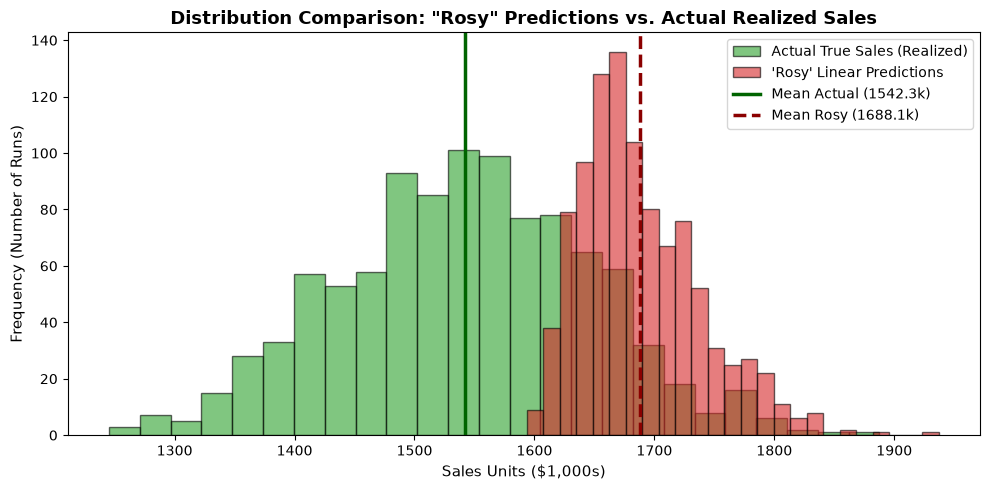

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot Actual Sales Distribution
plt.hist(
    exp_df['Actual_Realized'], 
    bins=25, 
    color='#2ca02c', 
    alpha=0.6, 
    edgecolor='black', 
    label='Actual True Sales (Realized)'
)

# Plot Rosy Predictions Distribution
plt.hist(
    exp_df['Rosy_Forecast'], 
    bins=25, 
    color='#d62728', 
    alpha=0.6, 
    edgecolor='black', 
    label="'Rosy' Linear Predictions"
)

# Add Mean Reference Lines
mean_rosy = exp_df['Rosy_Forecast'].mean()
mean_actual = exp_df['Actual_Realized'].mean()

plt.axvline(mean_actual, color='darkgreen', linestyle='-', linewidth=2.5, label=f'Mean Actual ({mean_actual:.1f}k)')
plt.axvline(mean_rosy, color='darkred', linestyle='--', linewidth=2.5, label=f'Mean Rosy ({mean_rosy:.1f}k)')

# Formatting
plt.title('Distribution Comparison: "Rosy" Predictions vs. Actual Realized Sales', fontsize=13, fontweight='bold')
plt.xlabel('Sales Units ($1,000s)', fontsize=11)
plt.ylabel('Frequency (Number of Runs)', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()